In [ ]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 22.5726,
    "longitude": 88.3639,
    "start_date": "2015-01-01",
    "end_date": "2026-08-22",
    "hourly": "temperature_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "temperature_unit": "celsius",
    "precipitation_unit": "mm"
}

response = requests.get(url, params=params, timeout=120)
response.raise_for_status()

data = response.json()

df = pd.DataFrame(data["hourly"])

df.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature_c",
    "precipitation": "rainfall_mm"
}, inplace=True)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.to_csv("kolkata_weather.csv", index=False)

print("Dataset created!")
print("Rows:", len(df))
print(df.head())
print(df.tail())

Dataset created!
Rows: 102048
            timestamp  temperature_c  rainfall_mm
0 2015-01-01 00:00:00           18.1          0.0
1 2015-01-01 01:00:00           18.3          0.0
2 2015-01-01 02:00:00           18.4          0.0
3 2015-01-01 03:00:00           18.5          0.0
4 2015-01-01 04:00:00           18.6          0.0
                 timestamp  temperature_c  rainfall_mm
102043 2026-08-22 19:00:00           29.8          0.0
102044 2026-08-22 20:00:00           29.6          0.0
102045 2026-08-22 21:00:00           29.3          0.0
102046 2026-08-22 22:00:00           28.8          0.0
102047 2026-08-22 23:00:00           29.3          0.0


In [ ]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate timestamps:")
print(df["timestamp"].duplicated().sum())

print("\nTimestamp range:")
print(df["timestamp"].min(), "to", df["timestamp"].max())

print("\nTemperature statistics:")
print(df["temperature_c"].describe())

print("\nRainfall statistics:")
print(df["rainfall_mm"].describe())

print("\nRainfall observations:")
print((df["rainfall_mm"] > 0).sum())

print("\nMaximum rainfall in one hour:")
print(df["rainfall_mm"].max())

Shape: (102048, 3)

Missing values:
timestamp        0
temperature_c    0
rainfall_mm      0
dtype: int64

Duplicate timestamps:
0

Timestamp range:
2015-01-01 00:00:00 to 2026-08-22 23:00:00

Temperature statistics:
count    102048.000000
mean         26.178569
std           5.049097
min           8.700000
25%          23.600000
50%          27.000000
75%          29.300000
max          43.900000
Name: temperature_c, dtype: float64

Rainfall statistics:
count    102048.000000
mean          0.218632
std           0.955103
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          40.200000
Name: rainfall_mm, dtype: float64

Rainfall observations:
21498

Maximum rainfall in one hour:
40.2


In [ ]:
from google.colab import files
files.download("kolkata_weather.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# Basic EDA

print("Shape:")
print(df_v2.shape)

print("\nData types:")
print(df_v2.dtypes)

print("\nBasic statistics:")
display(df_v2.describe())

print("\nMissing values:")
print(df_v2.isnull().sum())

print("\nDuplicate rows:")
print(df_v2.duplicated().sum())

Shape:
(102048, 9)

Data types:
timestamp              datetime64[ns]
temperature_c                 float64
rainfall_mm                   float64
humidity_percent                int64
dew_point_c                   float64
pressure_hpa                  float64
wind_speed_kmh                float64
wind_direction_deg              int64
cloud_cover_percent             int64
dtype: object

Basic statistics:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
count,102048,102048.000000,102048.000000,102048.000000,102048.000000,102048.000000,102048.000000,102048.000000,102048.000000
mean,2020-10-26 23:30:00,26.178569,0.218632,77.047703,21.324207,1007.850316,9.053714,187.054269,50.445829
min,2015-01-01 00:00:00,8.700000,0.000000,11.000000,2.000000,965.800000,0.000000,1.000000,0.000000
25%,2017-11-28 23:45:00,23.600000,0.000000,67.000000,16.900000,1003.000000,5.800000,127.000000,2.000000
50%,2020-10-26 23:30:00,27.000000,0.000000,82.000000,23.900000,1007.900000,8.100000,185.000000,49.000000
75%,2023-09-24 23:15:00,29.300000,0.000000,91.000000,25.700000,1013.000000,11.500000,245.000000,98.000000
max,2026-08-22 23:00:00,43.900000,40.200000,100.000000,29.900000,1023.100000,68.900000,360.000000,100.000000
std,NaN,5.049097,0.955103,17.274390,5.334725,6.158180,4.790512,96.675709,42.504704



Missing values:
timestamp              0
temperature_c          0
rainfall_mm            0
humidity_percent       0
dew_point_c            0
pressure_hpa           0
wind_speed_kmh         0
wind_direction_deg     0
cloud_cover_percent    0
dtype: int64

Duplicate rows:
0


In [7]:
print("First timestamp:", df_v2["timestamp"].min())
print("Last timestamp:", df_v2["timestamp"].max())

# Check whether every timestamp is exactly 1 hour apart
time_diff = df_v2["timestamp"].diff().dropna()

print("\nTime intervals:")
print(time_diff.value_counts().head())

First timestamp: 2015-01-01 00:00:00
Last timestamp: 2026-08-22 23:00:00

Time intervals:
timestamp
0 days 01:00:00    102047
Name: count, dtype: int64


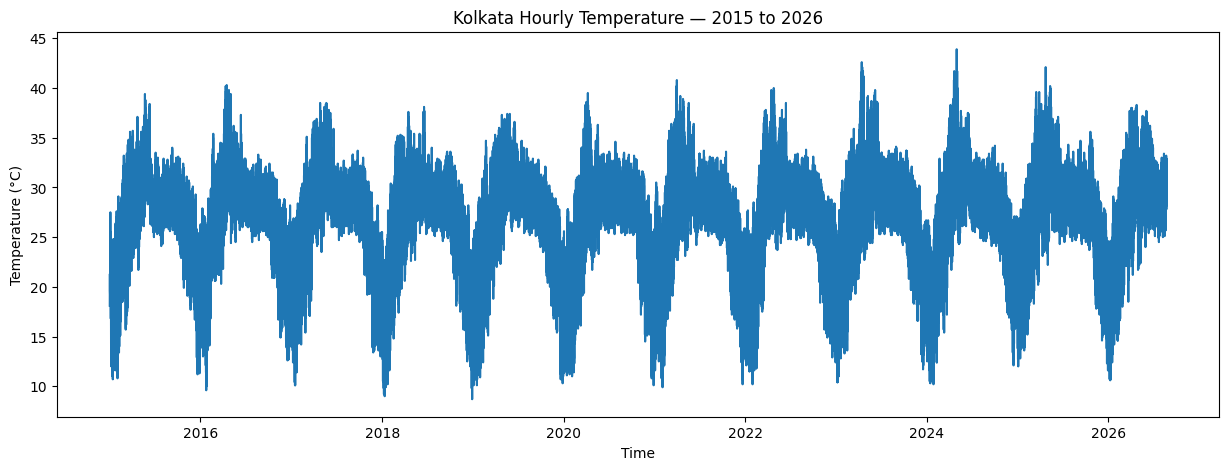

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df_v2["timestamp"], df_v2["temperature_c"])

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Kolkata Hourly Temperature — 2015 to 2026")

plt.show()

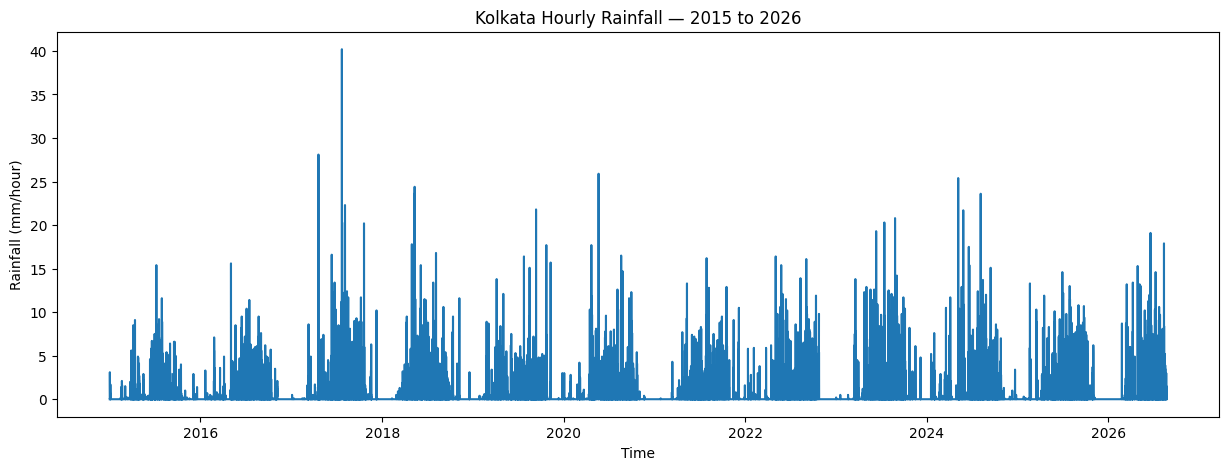

In [9]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_v2["timestamp"],
    df_v2["rainfall_mm"]
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hour)")
plt.title("Kolkata Hourly Rainfall — 2015 to 2026")

plt.show()

In [10]:
corr = df_v2.drop(columns=["timestamp"]).corr()

display(corr.round(2))

,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
temperature_c,1.00,0.05,-0.34,0.62,-0.62,0.30,-0.06,0.29
rainfall_mm,0.05,1.00,0.14,0.16,-0.20,0.13,-0.04,0.23
humidity_percent,-0.34,0.14,1.00,0.51,-0.27,0.00,-0.19,0.35
dew_point_c,0.62,0.16,0.51,1.00,-0.77,0.29,-0.22,0.55
pressure_hpa,-0.62,-0.20,-0.27,-0.77,1.00,-0.41,0.13,-0.55
wind_speed_kmh,0.30,0.13,0.00,0.29,-0.41,1.00,-0.05,0.21
wind_direction_deg,-0.06,-0.04,-0.19,-0.22,0.13,-0.05,1.00,-0.17
cloud_cover_percent,0.29,0.23,0.35,0.55,-0.55,0.21,-0.17,1.00


In [11]:
df_v2["month"] = df_v2["timestamp"].dt.month

monthly = df_v2.groupby("month").agg({
    "temperature_c": "mean",
    "rainfall_mm": "mean"
})

display(monthly.round(2))

,temperature_c,rainfall_mm
month,,
1,19.01,0.02
2,22.77,0.04
3,26.83,0.06
4,29.71,0.11
5,29.93,0.21
6,29.72,0.35
7,28.45,0.56
8,28.23,0.52
9,28.09,0.42


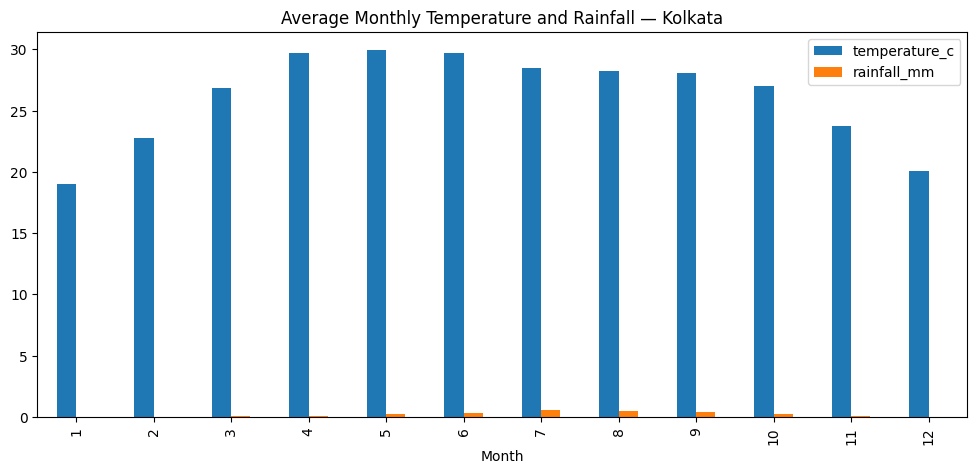

In [12]:
monthly.plot(
    y=["temperature_c", "rainfall_mm"],
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average Monthly Temperature and Rainfall — Kolkata")
plt.xlabel("Month")
plt.show()

In [13]:
import numpy as np
import pandas as pd

# Make a copy so V2 remains unchanged
df_ml = df_v2.copy()

# --------------------------------------------------
# 1. TIME FEATURES
# --------------------------------------------------

df_ml["hour"] = df_ml["timestamp"].dt.hour
df_ml["day_of_year"] = df_ml["timestamp"].dt.dayofyear
df_ml["month"] = df_ml["timestamp"].dt.month

# Cyclic encoding
df_ml["hour_sin"] = np.sin(2 * np.pi * df_ml["hour"] / 24)
df_ml["hour_cos"] = np.cos(2 * np.pi * df_ml["hour"] / 24)

df_ml["day_sin"] = np.sin(
    2 * np.pi * df_ml["day_of_year"] / 365.25
)

df_ml["day_cos"] = np.cos(
    2 * np.pi * df_ml["day_of_year"] / 365.25
)

# --------------------------------------------------
# 2. WIND DIRECTION
# --------------------------------------------------

wind_rad = np.deg2rad(df_ml["wind_direction_deg"])

df_ml["wind_direction_sin"] = np.sin(wind_rad)
df_ml["wind_direction_cos"] = np.cos(wind_rad)

# --------------------------------------------------
# 3. LAG FEATURES
# --------------------------------------------------

weather_columns = [
    "temperature_c",
    "rainfall_mm",
    "humidity_percent",
    "dew_point_c",
    "pressure_hpa",
    "wind_speed_kmh",
    "cloud_cover_percent"
]

lags = [1, 3, 6, 12, 24]

for column in weather_columns:
    for lag in lags:
        df_ml[f"{column}_lag_{lag}h"] = (
            df_ml[column].shift(lag)
        )

# --------------------------------------------------
# 4. FUTURE TARGETS
# --------------------------------------------------

# Predict weather 6 hours into the future

df_ml["target_temperature_6h"] = (
    df_ml["temperature_c"].shift(-6)
)

df_ml["target_rainfall_6h"] = (
    df_ml["rainfall_mm"].shift(-6)
)

# --------------------------------------------------
# 5. REMOVE UNUSABLE ROWS
# --------------------------------------------------

df_ml.dropna(inplace=True)

df_ml.reset_index(drop=True, inplace=True)

# --------------------------------------------------
# 6. CHECK DATASET
# --------------------------------------------------

print("ML Dataset shape:", df_ml.shape)

print("\nMissing values:")
print(df_ml.isnull().sum().sum())

print("\nFirst 5 rows:")
display(df_ml.head())

ML Dataset shape: (102018, 55)

Missing values:
0

First 5 rows:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent,month,...,wind_speed_kmh_lag_6h,wind_speed_kmh_lag_12h,wind_speed_kmh_lag_24h,cloud_cover_percent_lag_1h,cloud_cover_percent_lag_3h,cloud_cover_percent_lag_6h,cloud_cover_percent_lag_12h,cloud_cover_percent_lag_24h,target_temperature_6h,target_rainfall_6h
0,2015-01-02 00:00:00,19.3,0.0,93,18.2,1014.8,10.8,69,74,1,...,10.4,10.4,9.2,96.0,81.0,92.0,100.0,86.0,19.3,0.0
1,2015-01-02 01:00:00,19.3,0.0,93,18.1,1014.4,10.8,69,100,1,...,11.6,11.5,9.2,74.0,86.0,95.0,100.0,96.0,19.9,0.0
2,2015-01-02 02:00:00,19.3,0.0,92,18.0,1014.2,11.6,68,88,1,...,10.8,13.2,8.7,100.0,96.0,95.0,100.0,90.0,21.5,0.0
3,2015-01-02 03:00:00,19.3,0.0,92,18.0,1014.1,11.8,70,75,1,...,10.8,12.2,8.0,88.0,74.0,81.0,99.0,97.0,23.5,0.0
4,2015-01-02 04:00:00,19.2,0.0,92,17.9,1013.8,11.5,76,59,1,...,11.0,11.8,8.1,75.0,100.0,86.0,88.0,100.0,24.9,0.0


In [14]:
train_end = "2022-12-31 23:00:00"
val_end = "2024-12-31 23:00:00"

train_df = df_ml[df_ml["timestamp"] <= train_end].copy()

val_df = df_ml[
    (df_ml["timestamp"] > train_end) &
    (df_ml["timestamp"] <= val_end)
].copy()

test_df = df_ml[df_ml["timestamp"] > val_end].copy()

print("TRAIN:", train_df.shape)
print("VALIDATION:", val_df.shape)
print("TEST:", test_df.shape)

TRAIN: (70104, 55)
VALIDATION: (17544, 55)
TEST: (14370, 55)


In [15]:
import requests
import pandas as pd
import numpy as np

# ==============================
# DELHI LOCATION
# ==============================

LATITUDE = 28.6139
LONGITUDE = 77.2090

START_DATE = "2015-01-01"
END_DATE = "2026-08-22"

URL = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,

    "hourly": ",".join([
        "temperature_2m",
        "precipitation",
        "relative_humidity_2m",
        "dew_point_2m",
        "pressure_msl",
        "wind_speed_10m",
        "wind_direction_10m",
        "cloud_cover"
    ]),

    "timezone": "Asia/Kolkata",
    "temperature_unit": "celsius",
    "precipitation_unit": "mm",
    "wind_speed_unit": "kmh"
}

print("Downloading Delhi weather data...")

response = requests.get(
    URL,
    params=params,
    timeout=180
)

response.raise_for_status()

data = response.json()

df_delhi_v2 = pd.DataFrame(data["hourly"])

# Rename columns
df_delhi_v2.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature_c",
    "precipitation": "rainfall_mm",
    "relative_humidity_2m": "humidity_percent",
    "dew_point_2m": "dew_point_c",
    "pressure_msl": "pressure_hpa",
    "wind_speed_10m": "wind_speed_kmh",
    "wind_direction_10m": "wind_direction_deg",
    "cloud_cover": "cloud_cover_percent"
}, inplace=True)

# Timestamp
df_delhi_v2["timestamp"] = pd.to_datetime(
    df_delhi_v2["timestamp"]
)

# Sort
df_delhi_v2.sort_values(
    "timestamp",
    inplace=True
)

# Remove duplicate timestamps
df_delhi_v2.drop_duplicates(
    subset=["timestamp"],
    inplace=True
)

# Reset index
df_delhi_v2.reset_index(
    drop=True,
    inplace=True
)

# Save
df_delhi_v2.to_csv(
    "delhi_weather_v2.csv",
    index=False
)

print("\nDelhi V2 created!")
print("Shape:", df_delhi_v2.shape)

print("\nColumns:")
print(df_delhi_v2.columns.tolist())

print("\nMissing values:")
print(df_delhi_v2.isnull().sum())

print("\nFirst 5 rows:")
display(df_delhi_v2.head())

print("\nLast 5 rows:")
display(df_delhi_v2.tail())


Delhi V2 created!
Shape: (102048, 9)

Columns:
['timestamp', 'temperature_c', 'rainfall_mm', 'humidity_percent', 'dew_point_c', 'pressure_hpa', 'wind_speed_kmh', 'wind_direction_deg', 'cloud_cover_percent']

Missing values:
timestamp              0
temperature_c          0
rainfall_mm            0
humidity_percent       0
dew_point_c            0
pressure_hpa           0
wind_speed_kmh         0
wind_direction_deg     0
cloud_cover_percent    0
dtype: int64

First 5 rows:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
0,2015-01-01 00:00:00,12.2,0.0,86,10.0,1017.1,8.2,23,100
1,2015-01-01 01:00:00,12.9,0.0,81,9.8,1016.7,8.9,21,100
2,2015-01-01 02:00:00,13.2,0.0,79,9.7,1016.8,8.0,18,78
3,2015-01-01 03:00:00,13.1,0.0,79,9.6,1016.4,7.1,24,63
4,2015-01-01 04:00:00,13.0,0.0,80,9.6,1015.6,6.7,16,61



Last 5 rows:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
102043,2026-08-22 19:00:00,28.5,0.1,89,26.5,1001.9,8.9,173,31
102044,2026-08-22 20:00:00,27.9,0.0,89,25.9,1002.4,4.7,187,22
102045,2026-08-22 21:00:00,27.6,0.0,89,25.7,1003.0,4.8,200,47
102046,2026-08-22 22:00:00,27.3,0.0,87,25.0,1003.3,7.3,197,17
102047,2026-08-22 23:00:00,28.5,0.0,85,25.7,1003.2,7.3,171,3


In [16]:
print("Shape:", df_delhi_v2.shape)

print("\nMissing values:")
print(df_delhi_v2.isnull().sum())

print("\nDuplicate rows:")
print(df_delhi_v2.duplicated().sum())

print("\nTimestamp range:")
print(
    df_delhi_v2["timestamp"].min(),
    "to",
    df_delhi_v2["timestamp"].max()
)

print("\nTemperature statistics:")
print(df_delhi_v2["temperature_c"].describe())

print("\nRainfall statistics:")
print(df_delhi_v2["rainfall_mm"].describe())

print("\nRainy hours:")
print(
    (df_delhi_v2["rainfall_mm"] > 0).sum()
)

print("\nMaximum hourly rainfall:")
print(
    df_delhi_v2["rainfall_mm"].max()
)

Shape: (102048, 9)

Missing values:
timestamp              0
temperature_c          0
rainfall_mm            0
humidity_percent       0
dew_point_c            0
pressure_hpa           0
wind_speed_kmh         0
wind_direction_deg     0
cloud_cover_percent    0
dtype: int64

Duplicate rows:
0

Timestamp range:
2015-01-01 00:00:00 to 2026-08-22 23:00:00

Temperature statistics:
count    102048.000000
mean         24.725637
std           7.985430
min           2.000000
25%          18.800000
50%          26.100000
75%          30.300000
max          46.000000
Name: temperature_c, dtype: float64

Rainfall statistics:
count    102048.000000
mean          0.087911
std           0.587616
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          30.400000
Name: rainfall_mm, dtype: float64

Rainy hours:
10099

Maximum hourly rainfall:
30.4


In [17]:
time_diff = (
    df_delhi_v2["timestamp"]
    .diff()
    .dropna()
)

print(time_diff.value_counts().head())

timestamp
0 days 01:00:00    102047
Name: count, dtype: int64


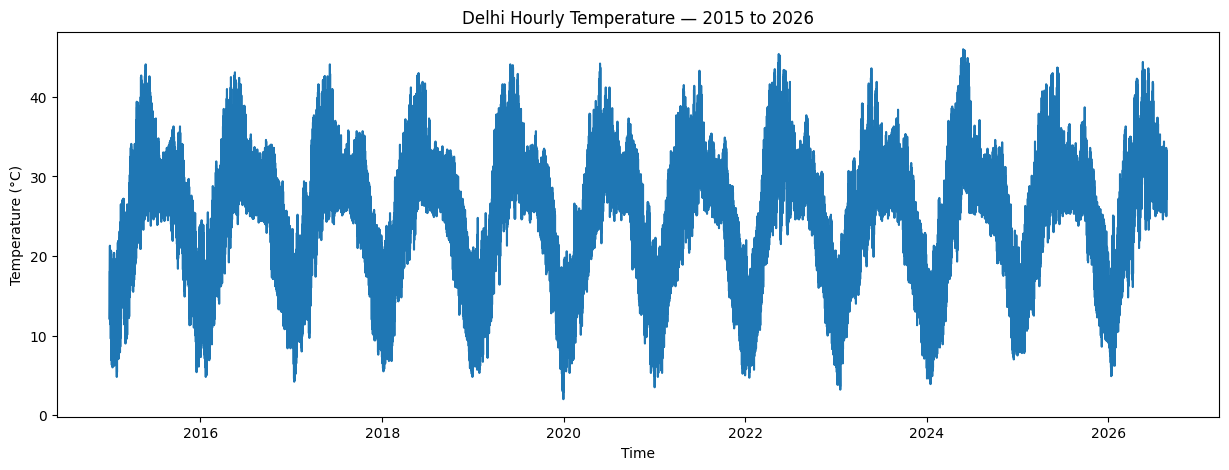

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    df_delhi_v2["timestamp"],
    df_delhi_v2["temperature_c"]
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Delhi Hourly Temperature — 2015 to 2026")

plt.show()

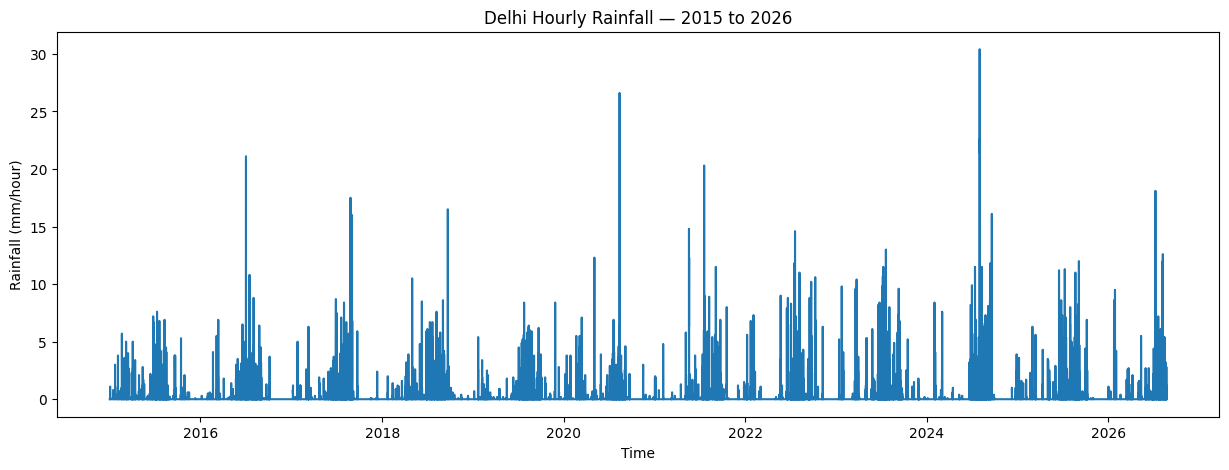

In [19]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_delhi_v2["timestamp"],
    df_delhi_v2["rainfall_mm"]
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hour)")
plt.title("Delhi Hourly Rainfall — 2015 to 2026")

plt.show()

In [20]:
corr_delhi = (
    df_delhi_v2
    .drop(columns=["timestamp"])
    .corr()
)

display(corr_delhi.round(2))

,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
temperature_c,1.00,0.02,-0.56,0.46,-0.78,0.19,-0.12,0.11
rainfall_mm,0.02,1.00,0.16,0.16,-0.12,0.03,-0.10,0.22
humidity_percent,-0.56,0.16,1.00,0.44,0.13,-0.26,-0.25,0.29
dew_point_c,0.46,0.16,0.44,1.00,-0.66,-0.09,-0.39,0.39
pressure_hpa,-0.78,-0.12,0.13,-0.66,1.00,-0.13,0.24,-0.26
wind_speed_kmh,0.19,0.03,-0.26,-0.09,-0.13,1.00,0.08,-0.02
wind_direction_deg,-0.12,-0.10,-0.25,-0.39,0.24,0.08,1.00,-0.25
cloud_cover_percent,0.11,0.22,0.29,0.39,-0.26,-0.02,-0.25,1.00


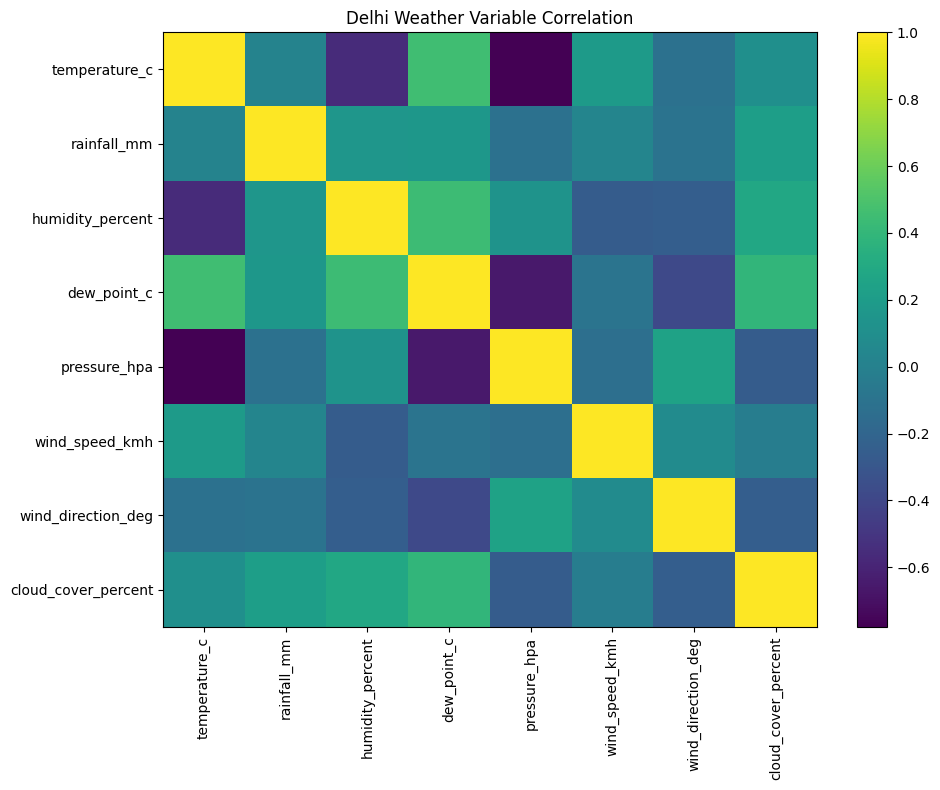

In [21]:
plt.figure(figsize=(10, 8))

plt.imshow(
    corr_delhi,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr_delhi.columns)),
    corr_delhi.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_delhi.columns)),
    corr_delhi.columns
)

plt.title("Delhi Weather Variable Correlation")

plt.tight_layout()
plt.show()

In [22]:
df_delhi_v2["month"] = (
    df_delhi_v2["timestamp"].dt.month
)

monthly_delhi = (
    df_delhi_v2
    .groupby("month")
    .agg({
        "temperature_c": "mean",
        "rainfall_mm": "mean"
    })
)

display(monthly_delhi.round(2))

,temperature_c,rainfall_mm
month,,
1,13.05,0.04
2,17.36,0.03
3,22.67,0.04
4,29.22,0.02
5,32.10,0.05
6,32.90,0.09
7,29.85,0.33
8,28.91,0.24
9,28.47,0.17


In [23]:
df_delhi_ml = df_delhi_v2.copy()

# ==============================
# TIME FEATURES
# ==============================

df_delhi_ml["hour"] = (
    df_delhi_ml["timestamp"].dt.hour
)

df_delhi_ml["day_of_year"] = (
    df_delhi_ml["timestamp"].dt.dayofyear
)

df_delhi_ml["month"] = (
    df_delhi_ml["timestamp"].dt.month
)

# Cyclic hour
df_delhi_ml["hour_sin"] = np.sin(
    2 * np.pi * df_delhi_ml["hour"] / 24
)

df_delhi_ml["hour_cos"] = np.cos(
    2 * np.pi * df_delhi_ml["hour"] / 24
)

# Cyclic day of year
df_delhi_ml["day_sin"] = np.sin(
    2 * np.pi *
    df_delhi_ml["day_of_year"] /
    365.25
)

df_delhi_ml["day_cos"] = np.cos(
    2 * np.pi *
    df_delhi_ml["day_of_year"] /
    365.25
)

# ==============================
# WIND DIRECTION
# ==============================

wind_rad = np.deg2rad(
    df_delhi_ml["wind_direction_deg"]
)

df_delhi_ml["wind_direction_sin"] = np.sin(
    wind_rad
)

df_delhi_ml["wind_direction_cos"] = np.cos(
    wind_rad
)

# ==============================
# LAG FEATURES
# ==============================

weather_columns = [
    "temperature_c",
    "rainfall_mm",
    "humidity_percent",
    "dew_point_c",
    "pressure_hpa",
    "wind_speed_kmh",
    "cloud_cover_percent"
]

lags = [1, 3, 6, 12, 24]

for column in weather_columns:

    for lag in lags:

        df_delhi_ml[
            f"{column}_lag_{lag}h"
        ] = (
            df_delhi_ml[column]
            .shift(lag)
        )

# ==============================
# 6-HOUR FUTURE TARGETS
# ==============================

df_delhi_ml["target_temperature_6h"] = (
    df_delhi_ml["temperature_c"].shift(-6)
)

df_delhi_ml["target_rainfall_6h"] = (
    df_delhi_ml["rainfall_mm"].shift(-6)
)

# ==============================
# REMOVE NaN
# ==============================

df_delhi_ml.dropna(inplace=True)

df_delhi_ml.reset_index(
    drop=True,
    inplace=True
)

print("Delhi ML dataset:")
print(df_delhi_ml.shape)

print("\nMissing values:")
print(df_delhi_ml.isnull().sum().sum())

Delhi ML dataset:
(102018, 55)

Missing values:
0


In [24]:
df_delhi_ml["location"] = "Delhi"
df_delhi_ml["latitude"] = 28.6139
df_delhi_ml["longitude"] = 77.2090

In [25]:
df_ml["location"] = "Kolkata"
df_ml["latitude"] = 22.5726
df_ml["longitude"] = 88.3639

In [26]:
df_delhi_ml.to_csv(
    "delhi_weather_ml_v3.csv",
    index=False
)

print("Delhi V3 saved successfully!")

Delhi V3 saved successfully!


In [27]:
from google.colab import files

files.download(
    "delhi_weather_ml_v3.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# Save Kolkata V3
df_ml.to_csv(
    "kolkata_weather_ml_v3.csv",
    index=False
)

print("Kolkata V3 saved!")
print("Shape:", df_ml.shape)

Kolkata V3 saved!
Shape: (102018, 58)


In [30]:
from google.colab import files

files.download("kolkata_weather_ml_v3.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>